# 전처리 & 머신러닝 통합 개인과제

## Part 2. 구매 고객 특성 분석 및 시각화

### 실무 시나리오

전자상거래 기업의 CRM팀은 모든 고객에게 동일한 프로모션을 제공하면서 마케팅 비용이 증가하고 있습니다.  
이에 데이터 분석팀은 Part 1에서 정제한 고객 데이터를 활용하여 **구매율과 구매금액이 높은 고객군을 찾고, 고객의 구매 행동을 설명할 수 있는 주요 변수를 확인**하려고 합니다.

수강생은 데이터 분석 담당자로서 다음 업무를 수행합니다.

1. 고객군별 구매 특성을 비교합니다.
2. 구매 행동의 분포와 변수 간 관계를 시각화합니다.
3. 분석 결과를 바탕으로 Part 3 구매예측 모델에 사용할 Feature 후보를 정리합니다.

> 문제 1~3은 필수 문제입니다.  
> 문제 4는 추가 분석을 위한 심화 문제이며 선택적으로 수행합니다.  
> 차트 종류와 표현 방식은 정해진 하나의 답만 있는 것이 아닙니다. 분석 목적에 적절하고 제목·축·범례가 명확하면 인정합니다.

## 과제 목표

- 전처리된 데이터의 주요 구매 현황을 확인할 수 있습니다.
- 두 개 이상의 기준으로 고객 데이터를 집계하고 집단별 구매 차이를 설명할 수 있습니다.
- 분석 목적에 적합한 차트를 선택하고 기본 시각 요소를 설정할 수 있습니다.
- EDA 결과를 근거로 머신러닝 Feature 후보를 제안할 수 있습니다.

## 사용 환경 및 데이터

- Python 3.X
- pandas, numpy
- `전자상거래_고객구매_전처리완료.csv`

# 문제 1. 주요 고객군의 구매 특성 비교

## 업무 상황

CRM팀은 프로모션 대상을 정하기 위해 어떤 고객군의 구매율과 구매금액이 높은지 확인하려고 합니다.  
전체 평균만 확인하면 집단별 차이를 알기 어렵기 때문에, 고객 특성을 기준으로 구매 실적을 비교해야 합니다.

## 필수 요구사항

1. 전처리 완료 데이터를 불러오고 데이터 크기와 주요 컬럼을 확인하세요.
2. 전체 고객 수, 구매 고객 수, 구매율과 주요 수치형 변수의 기초 통계량을 확인하세요.
3. 회원등급, 지역, 연령대, 선호 카테고리 중 적절한 기준을 선택하여 고객군별 구매 특성을 집계하세요.
4. **두 개 이상의 기준을 함께 사용한 그룹 집계**를 1개 이상 수행하세요.
5. 집계 결과를 바탕으로 구매율 또는 평균 구매금액이 높은 고객군을 간단히 설명하세요.

## 힌트

- 고객 수, 구매 고객 수, 구매율, 평균 구매금액, 평균 방문횟수 등을 집계 지표로 활용할 수 있습니다.
- 구매율이 높더라도 고객 수가 매우 적다면 해석에 주의해야 합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("전자상거래_고객구매_전처리완료.csv")

# TODO: 전처리 완료 데이터를 불러와 df에 저장하세요.
df = pd.read_csv(DATA_PATH)

# TODO: 데이터 크기, 주요 컬럼과 앞부분을 확인하세요.
print("데이터 크기:", df.shape)
print("주요 컬럼:", df.columns)
df.head()

데이터 크기: (1500, 17)
주요 컬럼: Index(['CustomerID', 'Gender', 'Age', 'Region', 'MembershipLevel',
       'VisitCount', 'AveragePurchaseAmount', 'TotalPurchaseAmount',
       'SatisfactionScore', 'LastPurchaseDate', 'CouponUsed',
       'PreferredCategory', 'SignupDate', 'Email', 'PurchaseStatus',
       'AgeGroup', 'PurchaseGrade'],
      dtype='str')


,CustomerID,Gender,Age,Region,MembershipLevel,VisitCount,AveragePurchaseAmount,TotalPurchaseAmount,SatisfactionScore,LastPurchaseDate,CouponUsed,PreferredCategory,SignupDate,Email,PurchaseStatus,AgeGroup,PurchaseGrade
0,CUST101486,Female,40,Unknown,Silver,5,75000.0,139800.0,3.7,2026-02-07,No,Beauty,2022-12-03,customer1486@example.com,0,40대,Low
1,CUST100113,Male,39,Gyeonggi,Basic,7,74400.0,159200.0,4.8,2026-04-22,No,Home,2021-07-16,customer113@example.com,1,30대,Low
2,CUST100168,Male,105,Gwangju,Silver,12,185800.0,1055800.0,4.5,2026-06-06,No,Beauty,2022-02-15,customer168@example.com,1,60대 이상,VIP
3,CUST101212,Male,44,Daegu,Vip,7,153900.0,413200.0,4.5,2026-05-07,No,Home,2021-10-27,customer1212@example.com,1,40대,High
4,CUST100312,Male,37,Gyeonggi,Basic,14,123700.0,576000.0,4.0,2026-04-16,No,Home,2025-11-08,customer312@example.com,1,30대,VIP


In [3]:
# TODO: 전체 고객 수, 구매 고객 수, 구매율과 주요 수치형 변수의 기초 통계량을 확인하세요.

total_customers = len(df) 
purchase_customers = (df['PurchaseStatus'] == 1).sum() 
purchase_rate = purchase_customers / total_customers * 100 

numeric_cols = [
    "Age",
    "VisitCount",
    "TotalPurchaseAmount",
    "AveragePurchaseAmount",
    "SatisfactionScore"
]

print("전체 고객 수:", total_customers)
print("구매 고객 수:", purchase_customers)
print("구매율:", purchase_rate, "%")

print("\n=== 주요 수치형 변수 기초 통계량 ===")
df[numeric_cols].describe()


전체 고객 수: 1500
구매 고객 수: 733
구매율: 48.86666666666667 %

=== 주요 수치형 변수 기초 통계량 ===


,Age,VisitCount,TotalPurchaseAmount,AveragePurchaseAmount,SatisfactionScore
count,1500.000000,1500.000000,1.500000e+03,1500.000000,1500.000000
mean,39.612000,9.482667,4.742260e+05,120280.266667,3.661133
std,11.546125,7.987087,1.336662e+06,52160.640642,0.750372
min,18.000000,1.000000,5.000000e+03,5000.000000,1.100000
25%,32.000000,7.000000,1.864250e+05,83975.000000,3.200000
50%,39.000000,9.000000,3.360500e+05,117500.000000,3.700000
75%,47.000000,11.000000,5.360250e+05,149750.000000,4.200000
max,130.000000,170.000000,3.000000e+07,292600.000000,5.000000


In [4]:
# TODO: 고객 특성 한 가지를 기준으로 구매 특성을 집계하세요.

purchase_by_membership = df.groupby(["MembershipLevel"]).agg(
    고객수=("CustomerID", "count"),
    구매고객수=("PurchaseStatus", "sum"),
    평균구매금액=("TotalPurchaseAmount", "mean"),
    평균방문횟수=("VisitCount", "mean")
)

purchase_by_membership["구매율"] = (
    purchase_by_membership["구매고객수"] / purchase_by_membership["고객수"] * 100
)

display(purchase_by_membership.round(2))

# TODO: 두 개 이상의 기준을 함께 사용하여 그룹 집계를 수행하세요.

purchase_by_group = df.groupby(["MembershipLevel", "AgeGroup"]).agg(
    고객수=("CustomerID", "count"),
    구매고객수=("PurchaseStatus", "sum"),
    평균구매금액=("TotalPurchaseAmount", "mean"),
    평균방문횟수=("VisitCount", "mean")
)

purchase_by_group["구매율"] = (
    purchase_by_group["구매고객수"] / purchase_by_group["고객수"] * 100
)

display(purchase_by_group.round(2))


,고객수,구매고객수,평균구매금액,평균방문횟수,구매율
MembershipLevel,,,,,
Basic,675,286,363237.19,9.67,42.37
Gold,276,167,635726.81,9.25,60.51
Silver,419,181,501095.70,9.47,43.20
Unknown,22,11,494172.73,9.55,50.00
Vip,108,88,646874.07,8.92,81.48


고객수  구매고객수      평균구매금액  평균방문횟수     구매율
MembershipLevel AgeGroup                                        
Basic           10대 이하     23      7   228595.65    7.43   30.43
                20대        89     38   328002.25   10.42   42.70
                30대       239     95   382176.57    9.82   39.75
                40대       215     89   385145.12    9.53   41.40
                50대        87     49   340977.01    9.78   56.32
                60대 이상     22      8   314718.18    8.32   36.36
Gold            10대 이하     11      5   366100.00    8.73   45.45
                20대        46     28   755713.04    8.87   60.87
                30대        92     60   500893.48    8.95   65.22
                40대        81     47   476424.69    9.62   58.02
                50대        33     20  1337078.79    9.67   60.61
                60대 이상     13      7   605730.77    9.85   53.85
Silver          10대 이하     14      6   508978.57   10.36   42.86
                20대        58     24   368122.41    8.34   41.38
                30대       141     67   407207.09   10.23   47.52
                40대       131     51   556203.82    9.10   38.93
                50대        60     27   757038.33    9.45   45.00
                60대 이상     15      6   385406.67    9.20   40.00
Unknown         10대 이하      1      0   523500.00   12.00    0.00
                20대         5      1   404760.00    8.00   20.00
                30대         6      4   603700.00   11.00   66.67
                40대         6      4   533733.33    9.17   66.67
                50대         4      2   374975.00    9.25   50.00
Vip             10대 이하      3      2   594400.00    9.00   66.67
                20대        21     20   652995.24    9.00   95.24
                30대        38     29   649465.79    8.63   76.32
                40대        33     25   656739.39    8.91   75.76
                50대         8      8   675575.00   10.50  100.00
                60대 이상      5      4   521920.00    8.20   80.00

### 문제 1 결과 정리

- 전체 구매 현황:
전체 평균 구매율은 약 48.87%이다. 

멤버십 등급별로 볼때, Basic 등급이 전체 고객의 약 45%(675명)를 차지하는 가장 큰 집단이며, 등급이 올라갈수록 고객 수가 감소하는 피라미드 구조이다.

- 구매율이 높은 고객군: 

Vip 등급이 81.48%(108명 중 88명 구매)로 가장 높고, Gold(60.51%), Silver(43.20%), Basic(42.37%) 순으로 등급이 높을수록 구매율이 상승한다.

- 평균 구매금액이 높은 고객군:

 Gold 50대가 약 133.7만 원(1,337,078.79원)으로 가장 높다. 

- 고객 수를 함께 고려했을 때 주의할 점:

표본수에 의한 착시를 주의해야 한다. 

Gold 50대의 경우 평균 구매금액이 133.7만 원으로 압도적이지만, 전체 고객 수는 33명(구매 고객 20명)에 불과하다.

특정 고액 구매자 1~2명의 영향으로 평균이 크게 왜곡되었을 가능성이 높으므로 이를 전체 50대 Gold의 일반적 특성으로 단정짓기는 위험하다.

Unknown 10대 이하(1명), Vip 10대 이하(3명), Vip 60대 이상(5명) 등 표본이 극소수인 구간의 평균치 역시 착시를 유발할 수 있다.

# 문제 2. 구매 행동의 분포와 관계 시각화

## 업무 상황

고객군별 평균만으로는 실제 데이터가 어느 구간에 집중되어 있는지, 일부 극단값이 평균에 영향을 주는지 알기 어렵습니다.  
CRM팀이 결과를 쉽게 이해할 수 있도록 구매 행동의 분포, 고객군 간 차이, 변수 간 관계를 시각화해야 합니다.

## 필수 요구사항

1. 구매금액, 방문횟수, 만족도 등 주요 수치형 변수 중 하나 이상의 분포를 시각화하세요.
2. 회원등급, 구매 여부 등 고객 집단별 차이를 비교할 수 있는 차트를 작성하세요.
3. 두 수치형 변수의 관계를 확인할 수 있는 차트를 작성하세요.
4. 모든 차트에 분석 내용을 이해할 수 있는 제목과 축 이름을 표시하고, 필요한 경우 범례를 추가하세요.
5. 차트에서 확인한 주요 패턴을 간단히 설명하세요.

## 힌트

- 분포 확인에는 히스토그램이나 박스플롯을 사용할 수 있습니다.
- 집단 비교에는 막대그래프나 그룹별 박스플롯을 사용할 수 있습니다.
- 수치형 변수 관계에는 산점도를 사용할 수 있습니다.

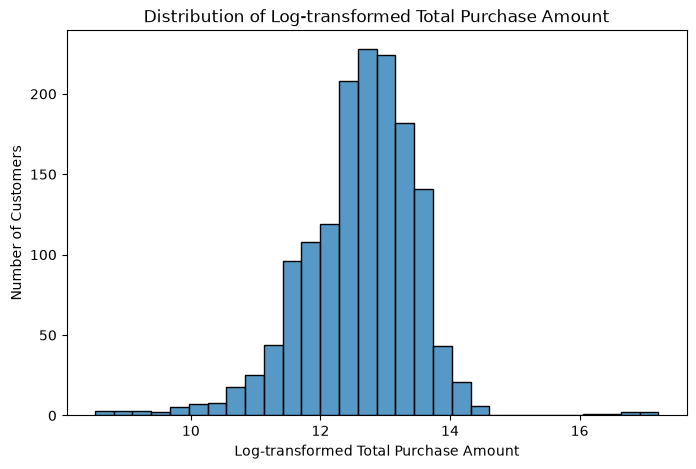

In [5]:
# TODO: 주요 수치형 변수의 분포를 시각화하세요.

# 이상치를 임의로 삭제하지 않고, 구매금액의 심한 왜도를 로그변환으로 완화해서 분포와 변수 간 관계를 보고자 함. 

# 구매금액 로그변환
df["LogTotalPurchaseAmount"] = np.log1p(df["TotalPurchaseAmount"])

# 총 구매금액 분포
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="LogTotalPurchaseAmount",
    bins=30
)

plt.title("Distribution of Log-transformed Total Purchase Amount")
plt.xlabel("Log-transformed Total Purchase Amount")
plt.ylabel("Number of Customers")

plt.show()


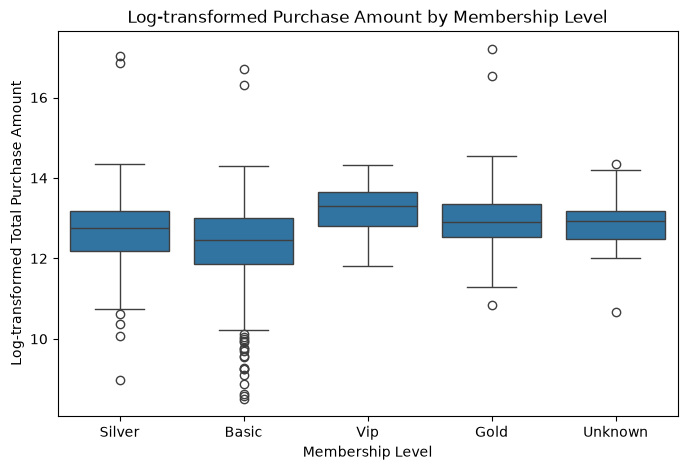

In [6]:
# TODO: 고객 집단별 구매 차이를 비교하는 차트를 작성하세요.

# 고객 멤버십등급에 따른 총구매금액 차이비교
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="MembershipLevel",
    y="LogTotalPurchaseAmount"
)

plt.title("Log-transformed Purchase Amount by Membership Level")
plt.xlabel("Membership Level")
plt.ylabel("Log-transformed Total Purchase Amount")

plt.show()

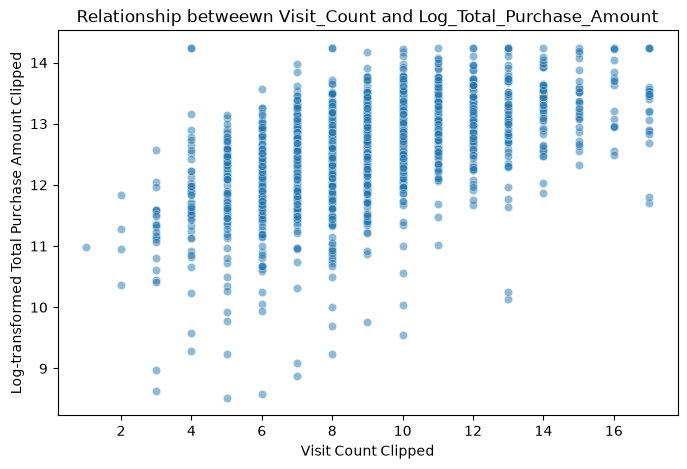

In [7]:
# TODO: 두 수치형 변수의 관계를 확인하는 차트를 작성하세요.

# 방문수와 총구매금액간의 관계

# 상위 1% Clipping
# 임계값 계산
x_limit = df['VisitCount'].quantile(0.99)
y_limit = df['LogTotalPurchaseAmount'].quantile(0.99)

# X축, Y축 각각 Clipping
df['Visit_Count_Clipped'] = df['VisitCount'].clip(upper=x_limit)
df['Log_Total_Purchase_Amount_Clipped'] = df['LogTotalPurchaseAmount'].clip(upper=y_limit)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Visit_Count_Clipped', y='Log_Total_Purchase_Amount_Clipped', alpha=0.5)
plt.title('Relationship betweewn Visit_Count and Log_Total_Purchase_Amount')
plt.xlabel("Visit Count Clipped")
plt.ylabel("Log-transformed Total Purchase Amount Clipped")
plt.show()


In [17]:
# df pickle로 저장(part3에서 사용하기 위해) 
model_df_log_clipped = df.copy()
model_df_log_clipped.to_pickle("model_df_log_clipped.pkl")

### 문제 2 결과 정리

- 주요 변수의 분포 특징: 
로그 변환을 통해 대다수 데이터가 중앙에 집중된 종 모양(정규분포)을 형성하고 있으나, 상·하단에 극단적인 아웃라이어가 일부 관찰되었다.

특히, 방문 횟수의 경우, 전체 고객의 대부분이 1~20회 구간에 조밀하게 밀집되어 있으며, 우측 꼬리가 매우 긴 왜곡된 분포가 나타난다.

- 고객 집단별 차이:

회원 등급에서 VIP 그룹의 구매 금액 중앙값이 미세하게 높을 뿐, 등급 간 분포 범위가 크게 상충하여 등급별 유의미한 금액 격차는 두드러지지 않아 보인다.

- 두 변수 사이에서 확인한 관계: 

방문 횟수가 증가함에 따라 총 구매 금액도 완만하게 상승하는 양(Positive)의 선형 관계를 형성함.

- 시각화 결과가 고객 분석에 주는 의미:

회원 등급이나 단순 만족도 지표보다 고객의 방문 횟수가 실제 매출을 결정짓는 지표로 작용하는듯 보인다.

# 문제 3. 구매예측 모델링 Feature 후보 정리

## 업무 상황

Part 3에서는 고객의 구매 여부를 예측하는 머신러닝 모델을 개발합니다.  
모델에 모든 컬럼을 그대로 넣기보다, 이번 EDA에서 구매 행동과 관련성이 확인된 변수와 제외해야 할 변수를 구분해야 합니다.

## 필수 요구사항

1. 수치형 변수와 `PurchaseStatus`의 관계를 확인할 수 있는 표 또는 시각화를 작성하세요.
2. 문제 1과 문제 2의 분석 결과를 바탕으로 모델링에 사용할 Feature 후보를 정리하세요.
3. 고객 식별자처럼 일반적인 구매 패턴 학습에 적절하지 않은 컬럼을 제외 후보로 구분하세요.
4. 각 Feature 후보를 선정한 근거를 EDA 결과와 연결하여 간단히 설명하세요.

## 힌트

- 상관계수는 수치형 변수 사이의 선형 관계를 확인하는 참고 자료입니다.
- 상관계수가 낮더라도 범주형 변수나 비선형 관계를 가진 변수는 모델에 유용할 수 있습니다.
- 고객 ID와 같은 고유 식별자는 새로운 고객의 구매 패턴을 일반화하는 데 적절하지 않을 수 있습니다.

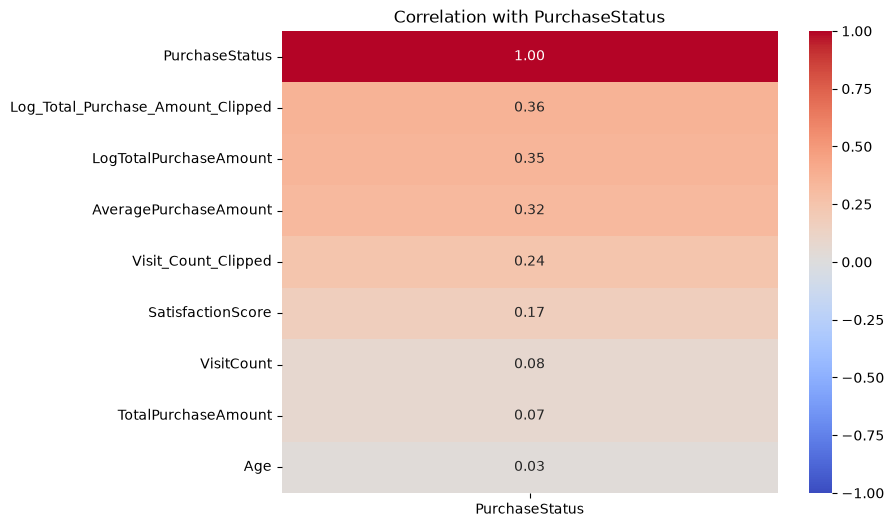

Visit_Count_Clipped                   \
                              mean median       std   
PurchaseStatus                                        
0                         8.346871    8.0  2.768863   
1                         9.785948   10.0  2.942253   

               Log_Total_Purchase_Amount_Clipped                       \
                                            mean     median       std   
PurchaseStatus                                                          
0                                      12.301430  12.419978  0.850220   
1                                      12.918152  13.006281  0.729398   

               SatisfactionScore                   
                            mean median       std  
PurchaseStatus                                     
0                       3.536375    3.6  0.755619  
1                       3.791678    3.8  0.722624

In [8]:
# TODO: 수치형 변수와 PurchaseStatus의 관계를 확인하세요.
# 수치형 변수들과 PurchaseStatus 간의 상관계수 계산 및 시각화
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix[['PurchaseStatus']].sort_values(
        by='PurchaseStatus', ascending=False
    ),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmax=1,
    vmin=-1,
)
plt.title('Correlation with PurchaseStatus')
plt.show()

# PurchaseStatus 그룹별 주요 수치형 변수의 기술통계량 비교 표 생성
numeric_features = [
    'Visit_Count_Clipped',
    'Log_Total_Purchase_Amount_Clipped',
    'SatisfactionScore',
]
summary_by_status = df.groupby('PurchaseStatus')[numeric_features].agg(
    ['mean', 'median', 'std']
)
display(summary_by_status)

In [ ]:
# TODO: EDA 결과를 바탕으로 Feature 후보와 제외 후보를 정리하세요.

## Feature 후보
# 수치형:
# Log_Total_Purchase_Amount_Clipped, Visit_Count_Clipped
# 범주형: 
# MembershipLevel

## 제외할 컬럼:
# CustomerID (고유 식별자), TotalPurchaseAmount(전처리 전 원본), VisitCount(전처리 전 원본)


### 문제 3 결과 정리

#### 모델링 Feature 후보

- 수치형 Feature: 

Log_Total_Purchase_Amount_Clipped, Visit_Count_Clipped

- 범주형 Feature: 

MembershipLevel

- 선정 근거:
Log_Total_Purchase_Amount_Clipped: 

PurchaseStatus와의 상관계수가 0.36으로 수치형 변수 중 가장 높으며, 통계표상 구매 집단(1)의 평균(12.92)과 중앙값(13.01)이 비구매 집단(0)보다 명확히 높게 나타남.

Visit_Count_Clipped: 

클리핑 적용 전 상관계수(0.08)에 비해 클리핑 후 상관계수(0.24)가 상승함. 실제 구매 집단(1)의 방문 횟수 평균(9.79회)이 비구매 집단(8.35회)보다 높아 구매 여부를 설명하는 행동 지표로 활용할 가능성이 있다고 판단함.


MembershipLevel: 

VIP 등 특정 범주 그룹에서의 구매 패턴 차이를 반영하기 위해 범주형 변수로 포함함.


#### 제외 후보

- 제외할 컬럼:

CustomerID (고유 식별자), TotalPurchaseAmount (전처리 전 원본), VisitCount (전처리 전 원본)

- 제외 이유:

CustomerID: 

단순 고유 인덱스로 패턴 일반화에 기여하지 못하고 모델의 과적합(Overfitting)을 유발함.

TotalPurchaseAmount / VisitCount: 

극단적 아웃라이어 및 우측 쏠림(Skewness)으로 인해 상관계수가 각각 0.07, 0.08로 매우 낮음. 

--> 이상치 전처리를 완료한 _Clipped 변수로 대체 가능하므로 중복방지를 위해 원본은 제외함.



# (심화)문제 4. 분석 결과의 심화 해석

## 업무 상황

CRM팀은 기본 분석 결과를 실제 마케팅과 구매예측 모델에 적용하기 전에,
고객군별 결과의 활용 가능성과 해석상의 주의점, 모델링 변수 구성의 위험 요소를 추가로 확인하려고 합니다.

## 요구사항

### 4-1. 고객군 활용 방안 제안

1. 문제 1의 집계 결과를 바탕으로 우선 관리할 고객군을 한 개 이상 선정하세요.
2. 해당 고객군을 선정한 근거를 구매율, 평균 구매금액, 고객 수 등의 지표와 연결하여 작성하세요.
3. 선정한 고객군에 적용할 수 있는 마케팅 활용 방안을 한 가지 이상 제안하세요.

### 4-2. 시각화 결과 해석 시 주의점

1. 문제 2의 분포 또는 집단 비교 차트에서 확인되는 치우침, 극단값, 집단별 차이 중 하나 이상을 설명하세요.
2. 해당 결과를 해석할 때 주의해야 할 점을 작성하세요.
3. 필요하다면 기존 분석을 보완하는 추가 차트를 한 개 작성하세요.

### 4-3. 모델링 Feature 위험 요소 검토

1. 서로 비슷한 정보를 제공하여 중복 가능성이 있는 변수를 한 쌍 이상 제시하세요.
2. 예측 시점에 사용할 수 없거나 구매 결과를 직접 반영하여 데이터 누수 가능성이 있는 변수를 검토하세요.
3. 최종 Feature 구성을 수치형 변수와 범주형 변수로 나누어 정리하세요.



## 심화 문제 결과 작성

### 4-1. 고객군 활용 방안

- 우선 관리할 고객군:
- 선정 근거:
- 제안할 마케팅 활용 방안:

### 4-2. 시각화 해석 시 주의점

- 확인한 분포 또는 집단 차이:
- 해석 시 주의할 점:
- 추가로 작성한 차트와 확인 결과:

### 4-3. Feature 위험 요소

- 중복 정보 가능성이 있는 변수:
- 데이터 누수 가능성이 있는 변수:
- 최종 수치형 Feature:
- 최종 범주형 Feature:



# 제출 결과물

## 필수 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 전체 구매 현황 | 전체 고객 수, 구매 고객 수, 구매율, 주요 기초 통계량 |
| 고객군별 집계표 | 단일 기준 및 두 개 이상 기준의 그룹 집계 |
| 고객군 해석 | 구매율 또는 평균 구매금액이 높은 고객군 설명 |
| 주요 시각화 | 분포, 고객 집단 비교, 두 수치형 변수 관계 차트 |
| Feature 후보 | 모델링에 사용할 Feature와 제외 후보 및 선정 근거 |

## 심화 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 고객군 활용 방안 | 우선 관리 고객군과 마케팅 제안 |
| 시각화 해석 주의점 | 치우침·극단값·집단 차이 해석과 주의사항 |
| Feature 위험 검토 | 중복 정보와 데이터 누수 가능성 검토 |
| 최종 Feature 구성 | 수치형·범주형 Feature 구분 |

# 제출 전 체크리스트

## 필수 체크리스트

- [ ] Part 1 전처리 완료 데이터를 사용했습니다.
- [ ] 전체 구매 현황과 주요 기초 통계량을 확인했습니다.
- [ ] 두 개 이상의 기준을 사용한 그룹 집계를 수행했습니다.
- [ ] 구매 특성이 두드러진 고객군을 설명했습니다.
- [ ] 분포, 집단 비교, 변수 관계를 확인할 수 있는 시각화를 작성했습니다.
- [ ] 차트에 제목, 축 이름과 필요한 범례를 표시했습니다.
- [ ] EDA 결과를 바탕으로 Feature 후보와 제외 후보를 정리했습니다.

## 심화 체크리스트

- [ ] 우선 관리할 고객군과 마케팅 활용 방안을 제안했습니다.
- [ ] 분포 또는 집단 차이를 해석할 때의 주의점을 설명했습니다.
- [ ] 필요에 따라 추가 차트를 작성했습니다.
- [ ] 중복 정보 가능성이 있는 변수를 검토했습니다.
- [ ] 데이터 누수 가능성이 있는 변수를 검토했습니다.
- [ ] 최종 Feature를 수치형과 범주형으로 구분했습니다.
